In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
df = pd.read_csv('all.csv')
X = df['YS(MPa)'].values.reshape(-1, 1)
y = df['HV(GPa)'].values

Text(0, 0.5, 'Hardness HV (GPa)')

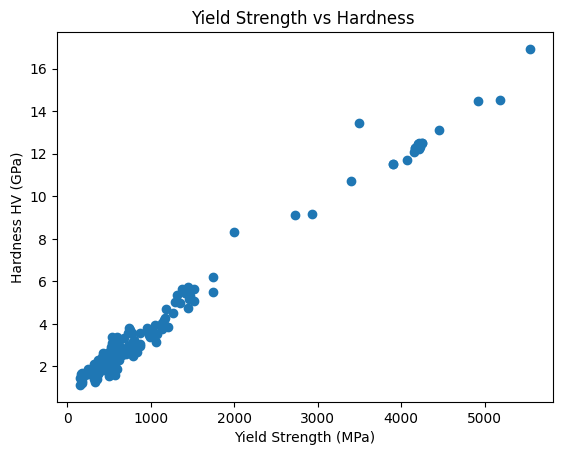

In [28]:
plt.scatter(X,y)

plt.title('Yield Strength vs Hardness ')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Hardness HV (GPa)')

In [13]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [14]:
y_pred = model.predict(X)
residuals = y - y_pred
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)


In [15]:

outliers = np.abs(std_residuals) > 2

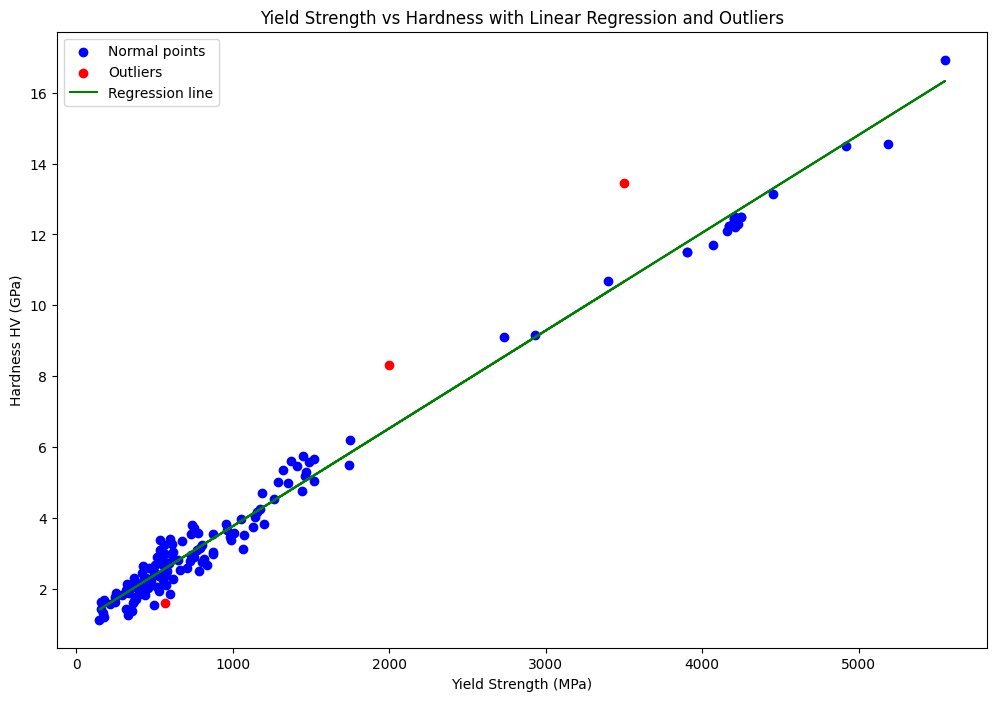

In [16]:
plt.figure(figsize=(12, 8))
plt.scatter(X[~outliers], y[~outliers], color='blue', label='Normal points')
plt.scatter(X[outliers], y[outliers], color='red', label='Outliers')
plt.plot(X, y_pred, color='green', label='Regression line')

plt.title('Yield Strength vs Hardness with Linear Regression and Outliers')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Hardness HV (GPa)')
plt.legend()

In [17]:

print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared: {r2_score(y, y_pred):.4f}")
print(f"Mean squared error: {mean_squared_error(y, y_pred):.4f}")

print("\nOutliers:")
print(df[outliers])

Slope: 0.0028
Intercept: 1.0101
R-squared: 0.9835
Mean squared error: 0.2178

Outliers:
    YS(MPa)    HV(GPa)
0   3500.00  13.450000
2   2000.00   8.310000
28   567.01   1.608485


In [19]:

df_clean = df[~outliers]
X_clean = df_clean['YS(MPa)'].values.reshape(-1, 1)
y_clean = df_clean['HV(GPa)'].values


In [20]:

model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)
y_pred_clean = model_clean.predict(X_clean)

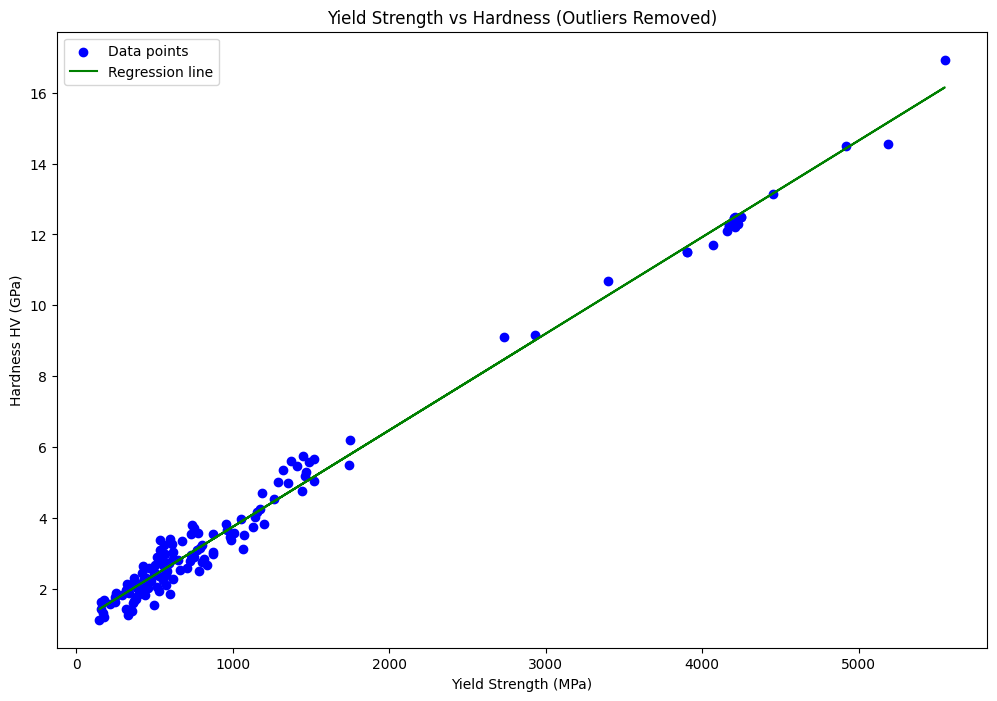

In [21]:

plt.figure(figsize=(12, 8))
plt.scatter(X_clean, y_clean, color='blue', label='Data points')
plt.plot(X_clean, y_pred_clean, color='green', label='Regression line')

plt.title('Yield Strength vs Hardness (Outliers Removed)')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Hardness HV (GPa)')
plt.legend()


In [22]:
print("Model statistics after removing outliers:")
print(f"Slope: {model_clean.coef_[0]:.4f}")
print(f"Intercept: {model_clean.intercept_:.4f}")
print(f"R-squared: {r2_score(y_clean, y_pred_clean):.4f}")
print(f"Mean squared error: {mean_squared_error(y_clean, y_pred_clean):.4f}")


Model statistics after removing outliers:
Slope: 0.0027
Intercept: 1.0270
R-squared: 0.9894
Mean squared error: 0.1357
